In [1]:
# Importando bibliotecas
from sys import getsizeof
import pandas as pd
import numpy as np
np.random.seed(42)

import matplotlib.pyplot as plt
import seaborn as sns
import os

# Instanciando uma DataFrame

In [2]:
# Criando listas de dados
letras = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
numeros = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
booleanos = [True, False, np.nan, True, False, np.nan, True, False, np.nan, True]
len(letras) == len(numeros) == len(booleanos)

True

In [3]:
# Instanciando um dicionário com as listas
dicionario = {
    'letras': letras,
    'numeros': numeros,
    'booleanos': booleanos,
}
dicionario

{'letras': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'],
 'numeros': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 'booleanos': [True, False, nan, True, False, nan, True, False, nan, True]}

In [4]:
# Instanciando um DataFrame a partir do dicionário
df = pd.DataFrame(dicionario)
df

,letras,numeros,booleanos
0,A,1,True
1,B,2,False
2,C,3,NaN
3,D,4,True
4,E,5,False
5,F,6,NaN
6,G,7,True
7,H,8,False
8,I,9,NaN
9,J,10,True


In [5]:
# Instanciando uma DataFrame a partir de um dicionário de listas
valores = {
    "valores": np.random.randint(1, 100, size=7),
    "letras": [i for i in "ABEFGIJ"]
}
df_2 = pd.DataFrame(valores)
df_2

,valores,letras
0,52,A
1,93,B
2,15,E
3,72,F
4,61,G
5,21,I
6,83,J


In [6]:
# Juntando os DataFrames utilizando a coluna 'letras' como chave
df.merge(df_2, on='letras')

,letras,numeros,booleanos,valores
0,A,1,True,52
1,B,2,False,93
2,E,5,False,15
3,F,6,NaN,72
4,G,7,True,61
5,I,9,NaN,21
6,J,10,True,83


In [7]:
# Utilizando o parâmetro 'how' para definir o tipo de junção
df.merge(df_2, on='letras', how='left')

,letras,numeros,booleanos,valores
0,A,1,True,52.0
1,B,2,False,93.0
2,C,3,NaN,NaN
3,D,4,True,NaN
4,E,5,False,15.0
5,F,6,NaN,72.0
6,G,7,True,61.0
7,H,8,False,NaN
8,I,9,NaN,21.0
9,J,10,True,83.0


In [8]:
# Utilizando o parâmetro 'how' para definir o tipo de junção
df.merge(df_2, on='letras', how='right')

,letras,numeros,booleanos,valores
0,A,1,True,52
1,B,2,False,93
2,E,5,False,15
3,F,6,NaN,72
4,G,7,True,61
5,I,9,NaN,21
6,J,10,True,83


In [9]:
# Utilizando o parâmetro 'how' para definir o tipo de junção
df.merge(df_2, on='letras', how='inner')

,letras,numeros,booleanos,valores
0,A,1,True,52
1,B,2,False,93
2,E,5,False,15
3,F,6,NaN,72
4,G,7,True,61
5,I,9,NaN,21
6,J,10,True,83


In [10]:
# Utilizando o parâmetro 'how' para definir o tipo de junção
df.merge(df_2, on='letras', how='outer')

,letras,numeros,booleanos,valores
0,A,1,True,52.0
1,B,2,False,93.0
2,C,3,NaN,NaN
3,D,4,True,NaN
4,E,5,False,15.0
5,F,6,NaN,72.0
6,G,7,True,61.0
7,H,8,False,NaN
8,I,9,NaN,21.0
9,J,10,True,83.0


In [11]:
# Concatenando os DataFrames utilizando o método concat
pd.concat([df, df_2], axis=0)

,letras,numeros,booleanos,valores
0,A,1.0,True,NaN
1,B,2.0,False,NaN
2,C,3.0,NaN,NaN
3,D,4.0,True,NaN
4,E,5.0,False,NaN
5,F,6.0,NaN,NaN
6,G,7.0,True,NaN
7,H,8.0,False,NaN
8,I,9.0,NaN,NaN
9,J,10.0,True,NaN


In [12]:
# Concatenando os DataFrames utilizando o método concat
pd.concat([df, df_2], axis=1)

,letras,numeros,booleanos,valores,letras
0,A,1,True,52.0,A
1,B,2,False,93.0,B
2,C,3,NaN,15.0,E
3,D,4,True,72.0,F
4,E,5,False,61.0,G
5,F,6,NaN,21.0,I
6,G,7,True,83.0,J
7,H,8,False,NaN,NaN
8,I,9,NaN,NaN,NaN
9,J,10,True,NaN,NaN


# Dados faltantes

In [13]:
# Instanciando um DataFrame a partir de um dicionário de listas
df_com_drop = pd.concat([df, df_2], axis=1)

# Removendo colunas do DataFrame utilizando o método drop
df_com_drop.drop(columns=['numeros', 'booleanos', 'valores'])

,letras,letras
0,A,A
1,B,B
2,C,E
3,D,F
4,E,G
5,F,I
6,G,J
7,H,NaN
8,I,NaN
9,J,NaN


In [14]:
# Removendo linhas do DataFrame utilizando o método drop
df_com_drop.drop(index=[0, 3, 4])

,letras,numeros,booleanos,valores,letras
1,B,2,False,93.0,B
2,C,3,NaN,15.0,E
5,F,6,NaN,21.0,I
6,G,7,True,83.0,J
7,H,8,False,NaN,NaN
8,I,9,NaN,NaN,NaN
9,J,10,True,NaN,NaN


In [15]:
# Removendo valores faltantes
df_com_drop.dropna()

,letras,numeros,booleanos,valores,letras
0,A,1,True,52.0,A
1,B,2,False,93.0,B
3,D,4,True,72.0,F
4,E,5,False,61.0,G
6,G,7,True,83.0,J


In [16]:
# Substituindo valores faltantes por um valor específico
df_com_drop.fillna(0)

,letras,numeros,booleanos,valores,letras
0,A,1,True,52.0,A
1,B,2,False,93.0,B
2,C,3,0,15.0,E
3,D,4,True,72.0,F
4,E,5,False,61.0,G
5,F,6,0,21.0,I
6,G,7,True,83.0,J
7,H,8,False,0.0,0
8,I,9,0,0.0,0
9,J,10,True,0.0,0


In [17]:
# Substituindo valores faltantes por um valor específico
modificando = lambda x: x.fillna(x.mean()) if x.dtype in ['float64', 'int64'] else x.fillna('Desconecido')
df_com_drop.apply(modificando)

,letras,numeros,booleanos,valores,letras
0,A,1,True,52.000000,A
1,B,2,False,93.000000,B
2,C,3,Desconecido,15.000000,E
3,D,4,True,72.000000,F
4,E,5,False,61.000000,G
5,F,6,Desconecido,21.000000,I
6,G,7,True,83.000000,J
7,H,8,False,56.714286,Desconecido
8,I,9,Desconecido,56.714286,Desconecido
9,J,10,True,56.714286,Desconecido


In [18]:
def substituir_faltantes(x, colunas: list = ['float64', 'int64']):
    if x.dtype in colunas:
        return x.fillna(x.mean())
    else:
        return x.fillna('Desconecido')

In [19]:
# Substituindo valores faltantes por um valor específico
df_com_drop.apply(substituir_faltantes)

,letras,numeros,booleanos,valores,letras
0,A,1,True,52.000000,A
1,B,2,False,93.000000,B
2,C,3,Desconecido,15.000000,E
3,D,4,True,72.000000,F
4,E,5,False,61.000000,G
5,F,6,Desconecido,21.000000,I
6,G,7,True,83.000000,J
7,H,8,False,56.714286,Desconecido
8,I,9,Desconecido,56.714286,Desconecido
9,J,10,True,56.714286,Desconecido


In [20]:
# Substituindo valores faltantes por um valor específico
df_com_drop.apply(substituir_faltantes, args=(['int32'],))

,letras,numeros,booleanos,valores,letras
0,A,1,True,52.0,A
1,B,2,False,93.0,B
2,C,3,Desconecido,15.0,E
3,D,4,True,72.0,F
4,E,5,False,61.0,G
5,F,6,Desconecido,21.0,I
6,G,7,True,83.0,J
7,H,8,False,Desconecido,Desconecido
8,I,9,Desconecido,Desconecido,Desconecido
9,J,10,True,Desconecido,Desconecido


In [21]:
# Preenchendo faltantes com dados anteriores
df_com_drop.ffill()

,letras,numeros,booleanos,valores,letras
0,A,1,True,52.0,A
1,B,2,False,93.0,B
2,C,3,False,15.0,E
3,D,4,True,72.0,F
4,E,5,False,61.0,G
5,F,6,False,21.0,I
6,G,7,True,83.0,J
7,H,8,False,83.0,J
8,I,9,False,83.0,J
9,J,10,True,83.0,J


In [22]:
# Preenchendo faltantes com dados posteriores
df_com_drop.bfill()

,letras,numeros,booleanos,valores,letras
0,A,1,True,52.0,A
1,B,2,False,93.0,B
2,C,3,True,15.0,E
3,D,4,True,72.0,F
4,E,5,False,61.0,G
5,F,6,True,21.0,I
6,G,7,True,83.0,J
7,H,8,False,NaN,NaN
8,I,9,True,NaN,NaN
9,J,10,True,NaN,NaN


# Encadeando métodos

In [23]:
df

,letras,numeros,booleanos
0,A,1,True
1,B,2,False
2,C,3,NaN
3,D,4,True
4,E,5,False
5,F,6,NaN
6,G,7,True
7,H,8,False
8,I,9,NaN
9,J,10,True


In [24]:
def fillna_com_soma(x, y):
    return x**y

In [25]:
# Encadeando operações de DataFrame
df_encadeia = (
    df.query('numeros < 10')
    .assign(soma_num=df.numeros.sum())
    .dropna()['soma_num']
    .pipe(fillna_com_soma, y=2)
    .sum()
)
df_encadeia

18150

# Importando dados de uma csv

In [26]:
# Obtendo lista de arquivos/pastas dentro do diretório "data"
os.listdir()

['aulas', 'data', 'exercicios', 'exercicios_resolvidos']

In [27]:
# Instanciando o DataFrame a partir do arquivo CSV
df_variaveis = pd.read_csv('./data/data_variable_edit.csv')
df_variaveis.shape

(180, 7)

# Verificando as caracteristicas da DataFrame

In [28]:
# Exibindo as primeiras linhas do DataFrame
df_variaveis.head()

,Sample,DV1 BR90,DV2 265,DV3 98,DV4 360,Cells,Treatment
0,Sample 1,44.54,39.56,81.42,48.23,CD4/CD8/CD19,Untreated
1,Sample 2,52.17,52.71,52.13,49.19,CD4/CD8/CD19,Untreated
2,Sample 3,45.37,52.28,42.48,50.88,CD4/CD8/CD19,Untreated
3,Sample 4,52.38,52.49,58.69,38.85,CD4/CD8/CD19,Untreated
4,Sample 5,49.51,51.85,51.10,47.40,CD4/CD8/CD19,Untreated


In [29]:
# Exibindo as últimas linhas do DataFrame
df_variaveis.tail()

,Sample,DV1 BR90,DV2 265,DV3 98,DV4 360,Cells,Treatment
175,Sample 2,0.45,0.45,0.45,0.45,CD8,Mock
176,Sample 3,0.58,0.58,0.58,0.58,CD8,Mock
177,Sample 4,0.76,0.76,0.76,0.76,CD8,Mock
178,Sample 5,0.60,0.60,0.60,0.60,CD8,Mock
179,Sample 6,0.65,0.65,0.65,0.65,CD8,Mock


In [30]:
# Exibindo informações gerais sobre o DataFrame
df_variaveis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Sample     180 non-null    object 
 1   DV1 BR90   180 non-null    float64
 2   DV2 265    180 non-null    float64
 3   DV3 98     180 non-null    float64
 4   DV4 360    180 non-null    float64
 5   Cells      180 non-null    object 
 6   Treatment  180 non-null    object 
dtypes: float64(4), object(3)
memory usage: 10.0+ KB


In [31]:
# Medidas resumo das colunas numéricas do DataFrame
df_variaveis.describe()

,DV1 BR90,DV2 265,DV3 98,DV4 360
count,180.000000,180.000000,180.000000,180.000000
mean,7.263833,7.413167,9.108333,6.624167
std,10.454712,10.944008,13.001236,10.534487
min,0.110000,0.110000,0.080000,0.010000
25%,1.387500,1.357500,1.067500,0.835000
50%,2.790000,2.595000,3.390000,1.970000
75%,6.900000,7.765000,12.047500,6.150000
max,52.380000,53.190000,81.420000,50.880000


In [32]:
# Selecionando apenas as colunas numéricas do DataFrame
df_variaveis.select_dtypes(include='number').head()

,DV1 BR90,DV2 265,DV3 98,DV4 360
0,44.54,39.56,81.42,48.23
1,52.17,52.71,52.13,49.19
2,45.37,52.28,42.48,50.88
3,52.38,52.49,58.69,38.85
4,49.51,51.85,51.10,47.40


In [33]:
# Medidas resumo das colunas numéricas do DataFrame
df_variaveis.select_dtypes(include='number').describe()

,DV1 BR90,DV2 265,DV3 98,DV4 360
count,180.000000,180.000000,180.000000,180.000000
mean,7.263833,7.413167,9.108333,6.624167
std,10.454712,10.944008,13.001236,10.534487
min,0.110000,0.110000,0.080000,0.010000
25%,1.387500,1.357500,1.067500,0.835000
50%,2.790000,2.595000,3.390000,1.970000
75%,6.900000,7.765000,12.047500,6.150000
max,52.380000,53.190000,81.420000,50.880000


In [34]:
# Selecionando apenas as colunas não numéricas do DataFrame
df_variaveis.select_dtypes(exclude='number').head()

,Sample,Cells,Treatment
0,Sample 1,CD4/CD8/CD19,Untreated
1,Sample 2,CD4/CD8/CD19,Untreated
2,Sample 3,CD4/CD8/CD19,Untreated
3,Sample 4,CD4/CD8/CD19,Untreated
4,Sample 5,CD4/CD8/CD19,Untreated


In [35]:
# Medidas resumo das colunas não numéricas do DataFrame
df_variaveis.select_dtypes(exclude='number').describe()

,Sample,Cells,Treatment
count,180,180,180
unique,6,6,5
top,Sample 1,CD4/CD8/CD19,Untreated
freq,30,30,36


# Indexação

In [36]:
# Selecionando apenas os valores faltantes
df_variaveis.query('Cells == "CD4/CD8/CD19"')

,Sample,DV1 BR90,DV2 265,DV3 98,DV4 360,Cells,Treatment
0,Sample 1,44.54,39.56,81.42,48.23,CD4/CD8/CD19,Untreated
1,Sample 2,52.17,52.71,52.13,49.19,CD4/CD8/CD19,Untreated
2,Sample 3,45.37,52.28,42.48,50.88,CD4/CD8/CD19,Untreated
3,Sample 4,52.38,52.49,58.69,38.85,CD4/CD8/CD19,Untreated
4,Sample 5,49.51,51.85,51.10,47.40,CD4/CD8/CD19,Untreated
5,Sample 6,50.16,53.19,50.76,46.78,CD4/CD8/CD19,Untreated
36,Sample 1,18.54,16.09,35.69,20.24,CD4/CD8/CD19,5 ug
37,Sample 2,18.45,18.82,25.13,18.12,CD4/CD8/CD19,5 ug
38,Sample 3,15.74,18.38,17.59,17.24,CD4/CD8/CD19,5 ug
39,Sample 4,18.78,18.80,26.13,15.90,CD4/CD8/CD19,5 ug


In [37]:
# Selecionando apenas os valores faltantes
try:
    print("Consulta com query.")
    df_variaveis.query('Cells == "CD4/CD8/CD19"' and "'DV4 360' >= 10.00")
except Exception as e:
    print(f"Erro: {e}")
finally:
    print("Consulta finalizada.")
    display(df_variaveis[
        (df_variaveis['DV4 360'] >= 10.00) & 
        (df_variaveis['Cells'] == "CD4/CD8/CD19")
    ])

Consulta com query.
Erro: '>=' not supported between instances of 'str' and 'float'
Consulta finalizada.


,Sample,DV1 BR90,DV2 265,DV3 98,DV4 360,Cells,Treatment
0,Sample 1,44.54,39.56,81.42,48.23,CD4/CD8/CD19,Untreated
1,Sample 2,52.17,52.71,52.13,49.19,CD4/CD8/CD19,Untreated
2,Sample 3,45.37,52.28,42.48,50.88,CD4/CD8/CD19,Untreated
3,Sample 4,52.38,52.49,58.69,38.85,CD4/CD8/CD19,Untreated
4,Sample 5,49.51,51.85,51.10,47.40,CD4/CD8/CD19,Untreated
5,Sample 6,50.16,53.19,50.76,46.78,CD4/CD8/CD19,Untreated
36,Sample 1,18.54,16.09,35.69,20.24,CD4/CD8/CD19,5 ug
37,Sample 2,18.45,18.82,25.13,18.12,CD4/CD8/CD19,5 ug
38,Sample 3,15.74,18.38,17.59,17.24,CD4/CD8/CD19,5 ug
39,Sample 4,18.78,18.80,26.13,15.90,CD4/CD8/CD19,5 ug


In [38]:
# Indexando o DataFrame utilizando a coluna 'id' de index como índice
print(df_variaveis.index[2])
df_variaveis.iloc[df_variaveis.index[2]]

2


Sample           Sample 3
DV1 BR90            45.37
DV2 265             52.28
DV3 98              42.48
DV4 360             50.88
Cells        CD4/CD8/CD19
Treatment       Untreated
Name: 2, dtype: object

In [39]:
# Indexando o DataFrame utilizando a coluna 'id' de coluna como índice
print(df_variaveis.columns[2])
df_variaveis[df_variaveis.columns[2]]

DV2 265


0      39.56
1      52.71
2      52.28
3      52.49
4      51.85
       ...  
175     0.45
176     0.58
177     0.76
178     0.60
179     0.65
Name: DV2 265, Length: 180, dtype: float64

In [40]:
# Indexando valores da segunda linha
df_variaveis.loc[1]

Sample           Sample 2
DV1 BR90            52.17
DV2 265             52.71
DV3 98              52.13
DV4 360             49.19
Cells        CD4/CD8/CD19
Treatment       Untreated
Name: 1, dtype: object

In [41]:
# Indexando todos os valores menos a última linha
df_variaveis.loc[-1:].head()

,Sample,DV1 BR90,DV2 265,DV3 98,DV4 360,Cells,Treatment
0,Sample 1,44.54,39.56,81.42,48.23,CD4/CD8/CD19,Untreated
1,Sample 2,52.17,52.71,52.13,49.19,CD4/CD8/CD19,Untreated
2,Sample 3,45.37,52.28,42.48,50.88,CD4/CD8/CD19,Untreated
3,Sample 4,52.38,52.49,58.69,38.85,CD4/CD8/CD19,Untreated
4,Sample 5,49.51,51.85,51.10,47.40,CD4/CD8/CD19,Untreated


In [42]:
# Indexando todos os valores da última linha para o início
df_variaveis.loc[::-1].head()

,Sample,DV1 BR90,DV2 265,DV3 98,DV4 360,Cells,Treatment
179,Sample 6,0.65,0.65,0.65,0.65,CD8,Mock
178,Sample 5,0.60,0.60,0.60,0.60,CD8,Mock
177,Sample 4,0.76,0.76,0.76,0.76,CD8,Mock
176,Sample 3,0.58,0.58,0.58,0.58,CD8,Mock
175,Sample 2,0.45,0.45,0.45,0.45,CD8,Mock


In [43]:
# Indexando todos os valores menos a primeira linha
df_variaveis.loc[-1:].tail()

,Sample,DV1 BR90,DV2 265,DV3 98,DV4 360,Cells,Treatment
175,Sample 2,0.45,0.45,0.45,0.45,CD8,Mock
176,Sample 3,0.58,0.58,0.58,0.58,CD8,Mock
177,Sample 4,0.76,0.76,0.76,0.76,CD8,Mock
178,Sample 5,0.60,0.60,0.60,0.60,CD8,Mock
179,Sample 6,0.65,0.65,0.65,0.65,CD8,Mock


In [44]:
# Demonstrando o revero de uma lista
print([1, 2, 3, 4, 5])
print([1, 2, 3, 4, 5][:-1])
print([1, 2, 3, 4, 5][-1:])
print([1, 2, 3, 4, 5][::-1])

[1, 2, 3, 4, 5]
[1, 2, 3, 4]
[5]
[5, 4, 3, 2, 1]


In [45]:
# Indexando os valores da coluna 'variavel' que sejam iguais a 'CD4' ou 'CD8'
df_variaveis[df_variaveis[df_variaveis.columns[-2]].isin(['CD4','CD8'])].head()

,Sample,DV1 BR90,DV2 265,DV3 98,DV4 360,Cells,Treatment
24,Sample 1,6.65,3.24,9.12,7.16,CD4,Untreated
25,Sample 2,6.40,5.83,8.08,6.14,CD4,Untreated
26,Sample 3,6.15,8.41,7.03,5.12,CD4,Untreated
27,Sample 4,6.40,5.83,8.08,6.14,CD4,Untreated
28,Sample 5,6.32,6.69,7.73,5.80,CD4,Untreated


In [46]:
# Indexando os valores da coluna 'variavel' que sejam diferentes de 'CD4' ou 'CD8'
df_variaveis[~df_variaveis[df_variaveis.columns[-2]].isin(['CD4','CD8'])].head()

,Sample,DV1 BR90,DV2 265,DV3 98,DV4 360,Cells,Treatment
0,Sample 1,44.54,39.56,81.42,48.23,CD4/CD8/CD19,Untreated
1,Sample 2,52.17,52.71,52.13,49.19,CD4/CD8/CD19,Untreated
2,Sample 3,45.37,52.28,42.48,50.88,CD4/CD8/CD19,Untreated
3,Sample 4,52.38,52.49,58.69,38.85,CD4/CD8/CD19,Untreated
4,Sample 5,49.51,51.85,51.10,47.40,CD4/CD8/CD19,Untreated


In [47]:
# Organizando os valores da DataFrame pela coluna 'Treatment'
df_variaveis.sort_values(by='Treatment').head()

,Sample,DV1 BR90,DV2 265,DV3 98,DV4 360,Cells,Treatment
89,Sample 6,1.52,1.19,3.20,1.36,CD14,10 ug
104,Sample 3,2.94,5.37,0.45,0.84,CD8,10 ug
103,Sample 2,3.72,2.46,0.42,1.08,CD8,10 ug
102,Sample 1,3.72,2.46,0.42,1.08,CD8,10 ug
101,Sample 6,1.36,1.67,0.31,0.15,CD4,10 ug


In [48]:
# Organizando a DataFrame segundo os index
df_variaveis.sort_index(ascending=False).head()

,Sample,DV1 BR90,DV2 265,DV3 98,DV4 360,Cells,Treatment
179,Sample 6,0.65,0.65,0.65,0.65,CD8,Mock
178,Sample 5,0.60,0.60,0.60,0.60,CD8,Mock
177,Sample 4,0.76,0.76,0.76,0.76,CD8,Mock
176,Sample 3,0.58,0.58,0.58,0.58,CD8,Mock
175,Sample 2,0.45,0.45,0.45,0.45,CD8,Mock


In [49]:
# Selecionando os 4 menores valores da coluna 'DV3 98'
df_variaveis['DV3 98'].nsmallest(4)

138    0.08
81     0.10
132    0.10
169    0.11
Name: DV3 98, dtype: float64

In [50]:
# Selecionando os 4 maiores valores da coluna 'DV3 98'
df_variaveis['DV3 98'].nlargest(4)

0     81.42
3     58.69
1     52.13
18    51.24
Name: DV3 98, dtype: float64

In [51]:
# Selecionando o index do menor valor da coluna 'DV3 98'
df_variaveis['DV3 98'].idxmin()

138

In [52]:
# Selecionando o index do maior valor da coluna 'DV3 98'
df_variaveis['DV3 98'].idxmax()

0

# Renomeando

In [53]:
# Renomeando a coluna 'Sample' para 'New Sample'
df_variaveis.rename(columns={'Sample': 'New Sample'}, index={"0": "d"}, inplace=True)
df_variaveis.head()

,New Sample,DV1 BR90,DV2 265,DV3 98,DV4 360,Cells,Treatment
0,Sample 1,44.54,39.56,81.42,48.23,CD4/CD8/CD19,Untreated
1,Sample 2,52.17,52.71,52.13,49.19,CD4/CD8/CD19,Untreated
2,Sample 3,45.37,52.28,42.48,50.88,CD4/CD8/CD19,Untreated
3,Sample 4,52.38,52.49,58.69,38.85,CD4/CD8/CD19,Untreated
4,Sample 5,49.51,51.85,51.10,47.40,CD4/CD8/CD19,Untreated


# Transformando

In [54]:
# Transpondo com T a DataFrame
df_variaveis.T.head()

,0,1,2,3,4,5,6,7,8,9,...,170,171,172,173,174,175,176,177,178,179
New Sample,Sample 1,Sample 2,Sample 3,Sample 4,Sample 5,Sample 6,Sample 1,Sample 2,Sample 3,Sample 4,...,Sample 3,Sample 4,Sample 5,Sample 6,Sample 1,Sample 2,Sample 3,Sample 4,Sample 5,Sample 6
DV1 BR90,44.54,52.17,45.37,52.38,49.51,50.16,23.44,25.76,29.13,25.75,...,0.88,0.6,0.53,0.67,1.26,0.45,0.58,0.76,0.6,0.65
DV2 265,39.56,52.71,52.28,52.49,51.85,53.19,19.5,26.92,35.21,26.92,...,0.88,0.6,0.53,0.67,1.26,0.45,0.58,0.76,0.6,0.65
DV3 98,81.42,52.13,42.48,58.69,51.1,50.76,27.48,32.45,36.23,32.06,...,0.88,0.6,0.53,0.67,1.26,0.45,0.58,0.76,0.6,0.65
DV4 360,48.23,49.19,50.88,38.85,47.4,46.78,25.89,27.97,29.84,28.35,...,0.88,0.6,0.53,0.67,1.26,0.45,0.58,0.76,0.6,0.65


In [55]:
# Contando os valores únicos da última coluna do DataFrame
df_variaveis[df_variaveis.columns[-1]].value_counts()

Untreated    36
5 ug         36
10 ug        36
20 ug        36
Mock         36
Name: Treatment, dtype: int64

In [56]:
# Convertendo a coluna 'Treatment' em variáveis dummy (booleanos)
pd.get_dummies(df_variaveis[df_variaveis.columns[-1]]).head()

,10 ug,20 ug,5 ug,Mock,Untreated
0,0,0,0,0,1
1,0,0,0,0,1
2,0,0,0,0,1
3,0,0,0,0,1
4,0,0,0,0,1


In [57]:
# Convertendo a coluna 'Treatment' em variáveis dummy (booleanos) e removendo a primeira coluna para evitar multicolinearidade
pd.get_dummies(df_variaveis[df_variaveis.columns[-1]], drop_first=True).head()

,20 ug,5 ug,Mock,Untreated
0,0,0,0,1
1,0,0,0,1
2,0,0,0,1
3,0,0,0,1
4,0,0,0,1


# Agrupando

In [58]:
# Contando os valores únicos da última coluna do DataFrame e convertendo em DataFrame
(
    df_variaveis.value_counts()
    .to_frame()
    .head()
)

0
New Sample DV1 BR90 DV2 265 DV3 98 DV4 360 Cells        Treatment   
Sample 1   0.52     0.76    0.08   0.13    CD8          20 ug      1
Sample 4   9.78     10.43   12.10  10.74   CD8          5 ug       1
           18.78    18.80   26.13  15.90   CD4/CD8/CD19 5 ug       1
           21.14    22.75   26.17  23.18   CD8          Untreated  1
           25.25    24.24   25.35  10.02   CD19         Untreated  1

In [59]:
# Exibindo as primeiras linhas do DataFrame
df_variaveis.head()

,New Sample,DV1 BR90,DV2 265,DV3 98,DV4 360,Cells,Treatment
0,Sample 1,44.54,39.56,81.42,48.23,CD4/CD8/CD19,Untreated
1,Sample 2,52.17,52.71,52.13,49.19,CD4/CD8/CD19,Untreated
2,Sample 3,45.37,52.28,42.48,50.88,CD4/CD8/CD19,Untreated
3,Sample 4,52.38,52.49,58.69,38.85,CD4/CD8/CD19,Untreated
4,Sample 5,49.51,51.85,51.10,47.40,CD4/CD8/CD19,Untreated


In [60]:
# Contando os valores únicos da primeira e última coluna do DataFrame e convertendo em DataFrame, renomeando a coluna de contagem e organizando por índice
coluna_1 = df_variaveis.columns[0]
coluna_2 = df_variaveis.columns[-1]
print(coluna_1, coluna_2)
display(
    df_variaveis.value_counts([
        coluna_1,
        coluna_2
    ])
    .to_frame()
    .rename(columns={0: 'Freq Abso Simp'})
    .sort_index()
 )

New Sample Treatment


Freq Abso Simp
New Sample Treatment                
Sample 1   10 ug                   6
           20 ug                   6
           5 ug                    6
           Mock                    6
           Untreated               6
Sample 2   10 ug                   6
           20 ug                   6
           5 ug                    6
           Mock                    6
           Untreated               6
Sample 3   10 ug                   6
           20 ug                   6
           5 ug                    6
           Mock                    6
           Untreated               6
Sample 4   10 ug                   6
           20 ug                   6
           5 ug                    6
           Mock                    6
           Untreated               6
Sample 5   10 ug                   6
           20 ug                   6
           5 ug                    6
           Mock                    6
           Untreated               6
Sample 6   10 ug                   6
           20 ug                   6
           5 ug                    6
           Mock                    6
           Untreated               6

In [61]:
# Agrupando os valores da coluna 'Cells' e somando os valores das colunas numéricas
(
    df_variaveis.iloc[:, [1, 2, 3, 4, 5]]
    .groupby('Cells')
    .sum()
)

,DV1 BR90,DV2 265,DV3 98,DV4 360
Cells,,,,
CD14,64.31,54.24,150.46,64.45
CD19,192.37,188.63,278.12,160.54
CD4,76.95,73.17,79.47,58.43
CD4/CD8,277.77,292.89,300.59,261.84
CD4/CD8/CD19,480.33,491.61,588.66,430.64
CD8,215.76,233.83,242.20,216.45


In [62]:
# Agrupando os valores das colunas 'Cells' e 'Treatment' e somando os valores das colunas numéricas
(
    df_variaveis.iloc[:, [1, 2, 3, 4, 5, 6]]
    .groupby(['Cells', 'Treatment'])
    .sum()
)

DV1 BR90  DV2 265  DV3 98  DV4 360
Cells        Treatment                                    
CD14         10 ug          8.52     7.26   22.61     9.72
             20 ug          8.50     8.50   15.94     8.50
             5 ug          13.09    10.66   33.06    12.80
             Mock           6.10     4.96    8.50     5.97
             Untreated     28.10    22.86   70.35    27.46
CD19         10 ug         14.95    14.60   59.73    12.94
             20 ug          9.35     9.35   17.40     9.35
             5 ug          31.49    30.85   57.50    25.90
             Mock           7.69     7.54    9.35     6.33
             Untreated    128.89   126.29  134.14   106.02
CD4          10 ug          7.91     7.64    1.59     0.67
             20 ug          9.60     8.74    4.43     1.24
             5 ug          17.64    16.22   22.21    16.88
             Mock           3.59     3.59    3.59     3.59
             Untreated     38.21    36.98   47.65    36.05
CD4/CD8      10 ug         25.58    27.53    2.66     4.52
             20 ug         13.38    12.48    5.93     1.83
             5 ug          73.54    76.90   89.38    78.73
             Mock           7.08     7.16    6.86     7.18
             Untreated    158.19   168.82  195.76   169.58
CD4/CD8/CD19 10 ug         41.27    42.86   62.18    18.04
             20 ug         23.13    22.23   23.58    11.56
             5 ug         106.67   109.38  149.71   105.93
             Mock          15.13    15.06   16.61    13.78
             Untreated    294.13   302.08  336.58   281.33
CD8          10 ug         19.04    21.16    2.53     5.16
             20 ug          4.81     4.77    2.93     1.60
             5 ug          58.50    63.09   72.44    64.10
             Mock           4.30     4.30    4.30     4.30
             Untreated    129.11   140.51  160.00   141.29

In [63]:
# Agrupando os valores das colunas 'Cells' e 'Treatment' e contando os valores das colunas numéricas
(
    df_variaveis.iloc[:, [1, 2, 3, 4, 5, 6]]
    .groupby(['Cells', 'Treatment'])
    .count()
)

DV1 BR90  DV2 265  DV3 98  DV4 360
Cells        Treatment                                    
CD14         10 ug             6        6       6        6
             20 ug             6        6       6        6
             5 ug              6        6       6        6
             Mock              6        6       6        6
             Untreated         6        6       6        6
CD19         10 ug             6        6       6        6
             20 ug             6        6       6        6
             5 ug              6        6       6        6
             Mock              6        6       6        6
             Untreated         6        6       6        6
CD4          10 ug             6        6       6        6
             20 ug             6        6       6        6
             5 ug              6        6       6        6
             Mock              6        6       6        6
             Untreated         6        6       6        6
CD4/CD8      10 ug             6        6       6        6
             20 ug             6        6       6        6
             5 ug              6        6       6        6
             Mock              6        6       6        6
             Untreated         6        6       6        6
CD4/CD8/CD19 10 ug             6        6       6        6
             20 ug             6        6       6        6
             5 ug              6        6       6        6
             Mock              6        6       6        6
             Untreated         6        6       6        6
CD8          10 ug             6        6       6        6
             20 ug             6        6       6        6
             5 ug              6        6       6        6
             Mock              6        6       6        6
             Untreated         6        6       6        6

In [64]:
# Agrupando os valores das colunas 'Cells' e 'Treatment' e calculando a média dos valores das colunas numéricas, arredondando para 2 casas decimais
(
    df_variaveis.iloc[:, [1, 2, 3, 4, 5, 6]]
    .groupby(['Cells', 'Treatment'])
    .mean()
    .round(2)
)

DV1 BR90  DV2 265  DV3 98  DV4 360
Cells        Treatment                                    
CD14         10 ug          1.42     1.21    3.77     1.62
             20 ug          1.42     1.42    2.66     1.42
             5 ug           2.18     1.78    5.51     2.13
             Mock           1.02     0.83    1.42     1.00
             Untreated      4.68     3.81   11.72     4.58
CD19         10 ug          2.49     2.43    9.96     2.16
             20 ug          1.56     1.56    2.90     1.56
             5 ug           5.25     5.14    9.58     4.32
             Mock           1.28     1.26    1.56     1.06
             Untreated     21.48    21.05   22.36    17.67
CD4          10 ug          1.32     1.27    0.26     0.11
             20 ug          1.60     1.46    0.74     0.21
             5 ug           2.94     2.70    3.70     2.81
             Mock           0.60     0.60    0.60     0.60
             Untreated      6.37     6.16    7.94     6.01
CD4/CD8      10 ug          4.26     4.59    0.44     0.75
             20 ug          2.23     2.08    0.99     0.30
             5 ug          12.26    12.82   14.90    13.12
             Mock           1.18     1.19    1.14     1.20
             Untreated     26.36    28.14   32.63    28.26
CD4/CD8/CD19 10 ug          6.88     7.14   10.36     3.01
             20 ug          3.86     3.70    3.93     1.93
             5 ug          17.78    18.23   24.95    17.65
             Mock           2.52     2.51    2.77     2.30
             Untreated     49.02    50.35   56.10    46.89
CD8          10 ug          3.17     3.53    0.42     0.86
             20 ug          0.80     0.80    0.49     0.27
             5 ug           9.75    10.52   12.07    10.68
             Mock           0.72     0.72    0.72     0.72
             Untreated     21.52    23.42   26.67    23.55

In [65]:
# Agrupando os valores das colunas 'Cells' e 'Treatment' e calculando a média dos valores das colunas numéricas, arredondando para 2 casas decimais
(
    df_variaveis.iloc[:, [1, 2, 3, 4, 5, 6]]
    .groupby(['Cells', 'Treatment'])
    .median()
    .round(2)
)

DV1 BR90  DV2 265  DV3 98  DV4 360
Cells        Treatment                                    
CD14         10 ug          1.42     1.26    3.60     1.72
             20 ug          1.43     1.43    2.64     1.43
             5 ug           2.20     1.84    5.55     2.08
             Mock           1.02     0.86    1.43     0.97
             Untreated      4.72     3.96   11.46     4.45
CD19         10 ug          2.50     2.42    7.38     2.28
             20 ug          1.58     1.58    2.70     1.58
             5 ug           5.28     5.18    8.98     4.61
             Mock           1.29     1.27    1.58     1.12
             Untreated     21.60    21.21   17.75    18.87
CD4          10 ug          1.35     1.30    0.24     0.11
             20 ug          1.58     1.48    0.74     0.23
             5 ug           2.86     2.76    3.56     2.69
             Mock           0.64     0.64    0.64     0.64
             Untreated      6.36     6.26    7.90     5.97
CD4/CD8      10 ug          4.09     4.47    0.44     0.77
             20 ug          2.19     2.13    0.89     0.35
             5 ug          12.03    12.84   14.68    12.86
             Mock           1.19     1.21    1.16     1.23
             Untreated     26.34    28.32   33.02    28.48
CD4/CD8/CD19 10 ug          7.02     7.35    7.76     3.14
             20 ug          3.82     3.77    3.94     2.00
             5 ug          18.04    18.64   24.04    17.29
             Mock           2.44     2.46    2.80     2.19
             Untreated     49.83    52.39   51.62    47.82
CD8          10 ug          2.97     3.40    0.42     0.80
             20 ug          0.79     0.78    0.48     0.29
             5 ug           9.68    10.54   12.02    10.57
             Mock           0.62     0.62    0.62     0.62
             Untreated     21.63    23.61   26.81    23.66

In [66]:
# Agrupando os valores das colunas 'Cells' e 'Treatment' e contando o número de valores únicos para cada Celula e Tratamento
display(df_variaveis.head(1))
pd.crosstab(
    df_variaveis[df_variaveis.columns[-2]],
    df_variaveis[df_variaveis.columns[-1]]
)

,New Sample,DV1 BR90,DV2 265,DV3 98,DV4 360,Cells,Treatment
0,Sample 1,44.54,39.56,81.42,48.23,CD4/CD8/CD19,Untreated


Treatment,10 ug,20 ug,5 ug,Mock,Untreated
Cells,,,,,
CD14,6,6,6,6,6
CD19,6,6,6,6,6
CD4,6,6,6,6,6
CD4/CD8,6,6,6,6,6
CD4/CD8/CD19,6,6,6,6,6
CD8,6,6,6,6,6


In [67]:
# Agrupando os valores das colunas 'New Sample' e 'Treatment' e contando o número de valores únicos para cada Amostra e Tratamento
display(df_variaveis.head(1))
pd.crosstab(
    df_variaveis[df_variaveis.columns[0]],
    df_variaveis[df_variaveis.columns[-1]]
)

,New Sample,DV1 BR90,DV2 265,DV3 98,DV4 360,Cells,Treatment
0,Sample 1,44.54,39.56,81.42,48.23,CD4/CD8/CD19,Untreated


Treatment,10 ug,20 ug,5 ug,Mock,Untreated
New Sample,,,,,
Sample 1,6,6,6,6,6
Sample 2,6,6,6,6,6
Sample 3,6,6,6,6,6
Sample 4,6,6,6,6,6
Sample 5,6,6,6,6,6
Sample 6,6,6,6,6,6


In [68]:
# Agrupando os valores das colunas 'New Sample' e 'Cell' e contando o número de valores únicos para cada Amostra e Célula
display(df_variaveis.head(1))
pd.crosstab(
    df_variaveis[df_variaveis.columns[0]],
    df_variaveis[df_variaveis.columns[-2]]
)

,New Sample,DV1 BR90,DV2 265,DV3 98,DV4 360,Cells,Treatment
0,Sample 1,44.54,39.56,81.42,48.23,CD4/CD8/CD19,Untreated


Cells,CD14,CD19,CD4,CD4/CD8,CD4/CD8/CD19,CD8
New Sample,,,,,,
Sample 1,5,5,5,5,5,5
Sample 2,5,5,5,5,5,5
Sample 3,5,5,5,5,5,5
Sample 4,5,5,5,5,5,5
Sample 5,5,5,5,5,5,5
Sample 6,5,5,5,5,5,5


In [69]:
# Somando os valores de Tratamento para cada amostra em DV1 BR90
display(df_variaveis.head(1))
df_variaveis.pivot_table(
    index=df_variaveis.columns[0],
    columns=df_variaveis.columns[-1],
    values=df_variaveis.columns[1],
    aggfunc=np.sum
)

,New Sample,DV1 BR90,DV2 265,DV3 98,DV4 360,Cells,Treatment
0,Sample 1,44.54,39.56,81.42,48.23,CD4/CD8/CD19,Untreated


Treatment,10 ug,20 ug,5 ug,Mock,Untreated
New Sample,,,,,
Sample 1,20.70,9.70,52.60,9.29,117.06
Sample 2,20.70,8.40,51.70,5.62,136.09
Sample 3,17.33,15.30,44.91,6.79,123.43
Sample 4,20.53,11.12,52.62,8.05,136.46
Sample 5,18.80,11.59,49.46,6.76,130.96
Sample 6,19.21,12.66,49.64,7.38,132.63


In [70]:
# Somando os valores de Tratamento para cada amostra em DV1 BR90
display(df_variaveis.head(1))
(
    df_variaveis.pivot_table(
        index=df_variaveis.columns[0],
        columns=df_variaveis.columns[-1],
        values=df_variaveis.columns[1],
        aggfunc=np.sum
    )
    .style
    .highlight_max(color='lightgreen')
    .highlight_min(color='salmon')
    .text_gradient(cmap='Blues')
)

,New Sample,DV1 BR90,DV2 265,DV3 98,DV4 360,Cells,Treatment
0,Sample 1,44.54,39.56,81.42,48.23,CD4/CD8/CD19,Untreated


Treatment,10 ug,20 ug,5 ug,Mock,Untreated
New Sample,,,,,
Sample 1,20.700000,9.700000,52.600000,9.290000,117.060000
Sample 2,20.700000,8.400000,51.700000,5.620000,136.090000
Sample 3,17.330000,15.300000,44.910000,6.790000,123.430000
Sample 4,20.530000,11.120000,52.620000,8.050000,136.460000
Sample 5,18.800000,11.590000,49.460000,6.760000,130.960000
Sample 6,19.210000,12.660000,49.640000,7.380000,132.630000


In [71]:
(
    df_variaveis['DV1 BR90']
    .to_frame()
    .sort_values(by="DV1 BR90", ascending=False)
    .head(10)
    .style
    .text_gradient(cmap='Blues')
)

,DV1 BR90
3,52.380000
1,52.170000
5,50.160000
4,49.510000
2,45.370000
0,44.540000
8,29.130000
11,27.190000
10,26.920000
7,25.760000


In [72]:
is_max = df_variaveis['DV1 BR90'] == df_variaveis['DV1 BR90'].max()
is_max.head()

0    False
1    False
2    False
3     True
4    False
Name: DV1 BR90, dtype: bool

In [73]:
def highlight_max(s):
    ''' 
        Highlight the maximum in a Series yellow.
            Parameters
            s : pd.Series
                The Series to highlight
            Returns
            seletor: list
                The list of styles to apply to each element in the Series
    '''
    is_max = s == s.max()
    seletor = ['background-color: green' if v else '' for v in is_max]
    return seletor

In [74]:
# Aplicando a função de destaque para o máximo em cada coluna do DataFrame, considerando apenas as linhas onde a coluna 'New Sample' seja igual a 'Sample 1'
df_variaveis_style = (
    df_variaveis[(df_variaveis['New Sample'] == "Sample 1")]
    .drop("New Sample", axis=1)
    .style
    .apply(highlight_max, axis=0)
)
df_variaveis_style

,DV1 BR90,DV2 265,DV3 98,DV4 360,Cells,Treatment
0,44.540000,39.560000,81.420000,48.230000,CD4/CD8/CD19,Untreated
6,23.440000,19.500000,27.480000,25.890000,CD4/CD8,Untreated
12,4.230000,4.100000,17.120000,6.180000,CD14,Untreated
18,20.000000,19.020000,51.240000,21.210000,CD19,Untreated
24,6.650000,3.240000,9.120000,7.160000,CD4,Untreated
30,18.200000,17.600000,22.330000,20.320000,CD8,Untreated
36,18.540000,16.090000,35.690000,20.240000,CD4/CD8/CD19,5 ug
42,13.400000,11.200000,16.030000,14.800000,CD4/CD8,5 ug
48,1.970000,1.910000,6.240000,2.880000,CD14,5 ug
54,4.890000,4.650000,18.670000,5.180000,CD19,5 ug


In [75]:
# Salvando o DataFrame estilizado em um arquivo HTML
df_variaveis_style.to_html("data/estilo_max.html")

In [76]:
# Somando os valores de Tratamento para cada amostra em DV2 265
display(df_variaveis.head(1))
df_variaveis.pivot_table(
    index=df_variaveis.columns[0],
    columns=df_variaveis.columns[-1],
    values=df_variaveis.columns[2],
    aggfunc=np.sum
)

,New Sample,DV1 BR90,DV2 265,DV3 98,DV4 360,Cells,Treatment
0,Sample 1,44.54,39.56,81.42,48.23,CD4/CD8/CD19,Untreated


Treatment,10 ug,20 ug,5 ug,Mock,Untreated
New Sample,,,,,
Sample 1,14.41,12.19,45.43,9.16,103.02
Sample 2,14.41,8.25,52.23,5.29,136.77
Sample 3,27.84,12.60,52.32,6.75,142.65
Sample 4,20.29,11.03,52.37,7.72,136.62
Sample 5,20.85,10.60,52.02,6.54,137.52
Sample 6,23.25,11.40,52.73,7.15,140.96


In [77]:
# Selecionando apenas as colunas numéricas do DataFrame e calculando a correlação entre elas
corr = df_variaveis.select_dtypes(include='number').corr()
corr

,DV1 BR90,DV2 265,DV3 98,DV4 360
DV1 BR90,1.000000,0.993118,0.927922,0.977658
DV2 265,0.993118,1.000000,0.906307,0.975256
DV3 98,0.927922,0.906307,1.000000,0.930340
DV4 360,0.977658,0.975256,0.930340,1.000000


In [78]:
# Recuperando um array de Trues do mesmo formato da correlação entre as colunas numéricas do DataFrame
array_true = np.ones_like(corr, dtype=bool)
array_true

array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

In [79]:
# Convertendo o array anterior em True/False pela diagonal
mask = np.triu(array_true)
mask

array([[ True,  True,  True,  True],
       [False,  True,  True,  True],
       [False, False,  True,  True],
       [False, False, False,  True]])

In [80]:
# Convertendo o array anterior em True/False pela diagonal inversa
np.tril(array_true)

array([[ True, False, False, False],
       [ True,  True, False, False],
       [ True,  True,  True, False],
       [ True,  True,  True,  True]])

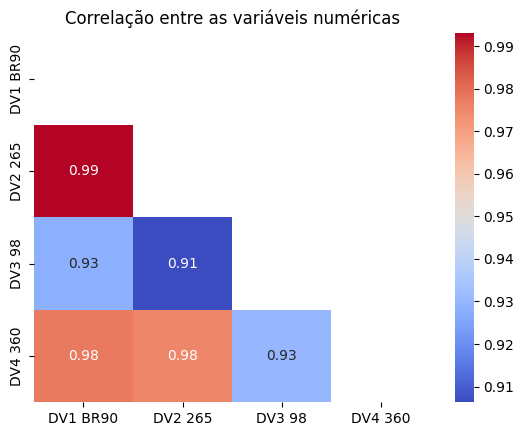

In [81]:
# Plotando a correlação entre as colunas numéricas do DataFrame utilizando o seaborn e aplicando a máscara para ocultar a parte superior da matriz de correlação
sns.heatmap(
    df_variaveis.select_dtypes(include='number').corr(),
    annot=True, 
    cmap='coolwarm',
    mask=mask
)
plt.title('Correlação entre as variáveis numéricas')
plt.show()

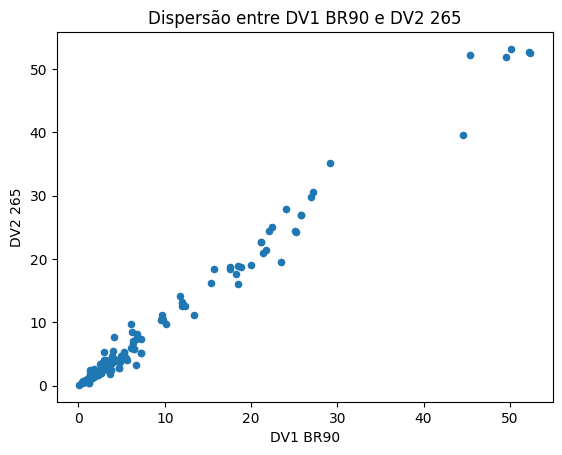

In [82]:
# Plotando a dispersão entre as colunas numéricas do DataFrame utilizando o matplotlib e colorindo os pontos de acordo com a coluna 'Treatment'
df_variaveis.plot.scatter(x=df_variaveis.columns[1], y=df_variaveis.columns[2])
plt.title(f'Dispersão entre {df_variaveis.columns[1]} e {df_variaveis.columns[2]}')
plt.xlabel(df_variaveis.columns[1])
plt.ylabel(df_variaveis.columns[2])
plt.show()

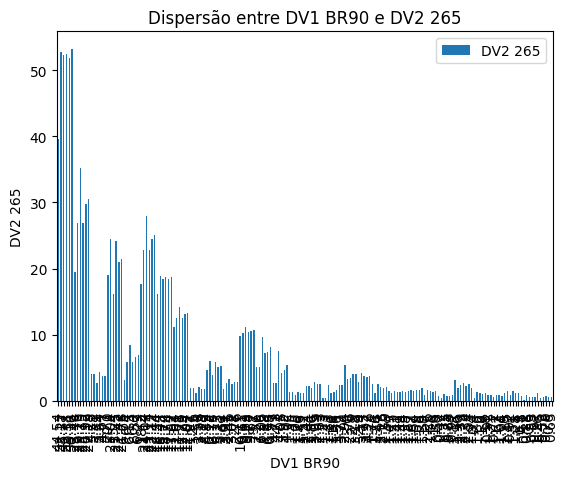

In [83]:
# Plotando a dispersão entre as colunas numéricas do DataFrame utilizando o matplotlib e colorindo os pontos de acordo com a coluna 'Treatment'
df_variaveis.plot.bar(x=df_variaveis.columns[1], y=df_variaveis.columns[2])
plt.title(f'Dispersão entre {df_variaveis.columns[1]} e {df_variaveis.columns[2]}')
plt.xlabel(df_variaveis.columns[1])
plt.ylabel(df_variaveis.columns[2])
plt.show()

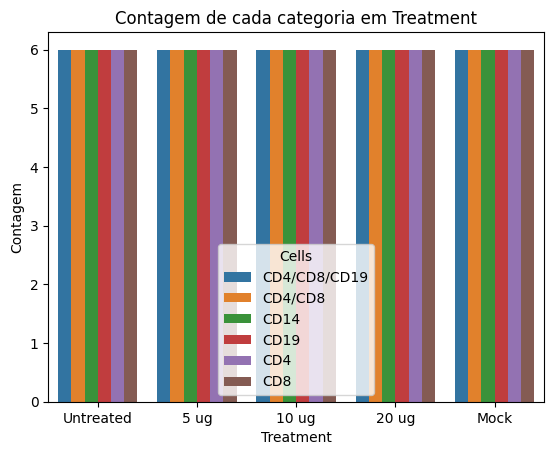

In [84]:
# Plotando a contagem de cada categoria da última coluna do DataFrame utilizando o seaborn e colorindo os pontos de acordo com a penúltima coluna
sns.countplot(x=df_variaveis.columns[-1], data=df_variaveis, hue=df_variaveis.columns[-2])
plt.title(f'Contagem de cada categoria em {df_variaveis.columns[-1]}')
plt.xlabel(df_variaveis.columns[-1])
plt.ylabel('Contagem')
plt.show()

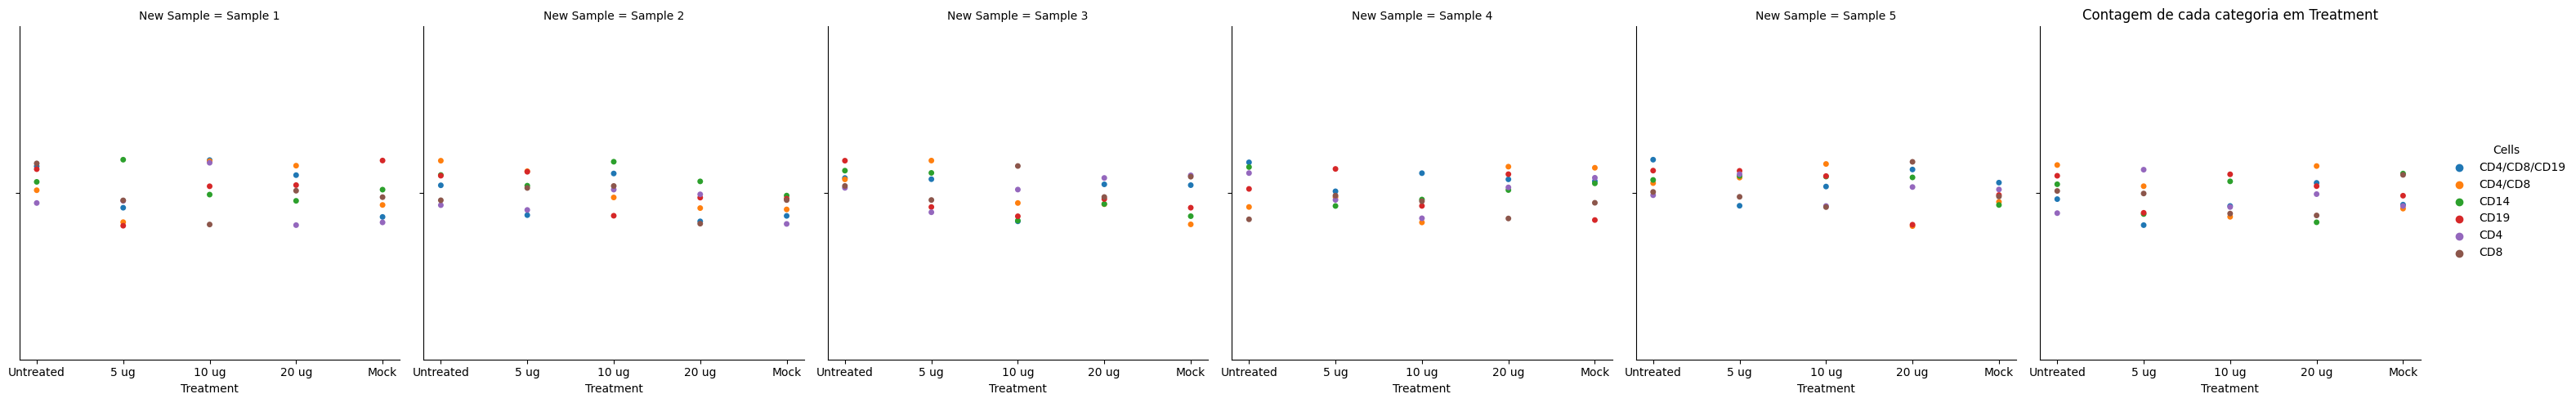

In [85]:
# Plotando a contagem de cada categoria da última coluna do DataFrame utilizando o 
# seaborn e colorindo os pontos de acordo com a penúltima coluna, e organizando por cada categoria da primeira coluna
sns.catplot(x=df_variaveis.columns[-1], data=df_variaveis, hue=df_variaveis.columns[-2], col=df_variaveis.columns[0])
plt.title(f'Contagem de cada categoria em {df_variaveis.columns[-1]}')
plt.xlabel(df_variaveis.columns[-1])
plt.ylabel('Contagem')
plt.show()

# Yield

In [86]:
# Criando um gerador que recebe um número e retorna o quadrado desse número
num = 5
def gerador(num: int) -> int:
    print(f"Recebndo : {num}")
    yield num * num

for number in gerador(num=num):
    print(number)

Recebndo : 5
25


In [87]:
# Criando um gerador que recebe um número e retorna o quadrado desse número e o dobro desse número
def gerador(num: int) -> int:
    for i in range(num):
        print(f"Recebndo : {num} e {i}")
        yield num * i

for number in gerador(num=num):
    print(number)

Recebndo : 5 e 0
0
Recebndo : 5 e 1
5
Recebndo : 5 e 2
10
Recebndo : 5 e 3
15
Recebndo : 5 e 4
20


In [88]:
# Criando um gerador que recebe um número e retorna o quadrado desse número e o dobro desse número
def gerador(num: int) -> int:
    for i in range(num):
        print(f"Recebndo : {num} e {i}")
        yield i * i

for number in gerador(num=num):
    print(number)

Recebndo : 5 e 0
0
Recebndo : 5 e 1
1
Recebndo : 5 e 2
4
Recebndo : 5 e 3
9
Recebndo : 5 e 4
16


In [89]:
# Criando um gerador que recebe um número e retorna o quadrado desse número e o dobro desse número
list_compr = [x for x in range(10)]
print(list_compr)
# >> [0, 1, 2, 3, 4, 5, 6, 7, 9, 10]

list_gener = (x for x in range(10))
print(list_gener)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
<generator object <genexpr> at 0x7c661b560430>


In [90]:
# Criando um gerador que recebe um número e retorna o quadrado desse número e o dobro desse número
list_gener = (x*x for x in range(10))

print(f"Teste-1: {next(list_gener)}")
print(f"Teste-2: {next(list_gener)}")
print(f"Teste-3: {next(list_gener)}")

for i in list_gener:
    print(f"Teste-4: {i}")

Teste-1: 0
Teste-2: 1
Teste-3: 4
Teste-4: 9
Teste-4: 16
Teste-4: 25
Teste-4: 36
Teste-4: 49
Teste-4: 64
Teste-4: 81


In [91]:
# Criando um gerador que recebe um número e retorna o quadrado desse número e o dobro desse número
def other_math(number):
    print('do the math with:', number)
  
def gen_squares_in_interval(x, y):
    for i in range(x, y):
        yield i*i

x, y = (10, 20)

for number in gen_squares_in_interval(x, y):
    other_math(number)

do the math with: 100
do the math with: 121
do the math with: 144
do the math with: 169
do the math with: 196
do the math with: 225
do the math with: 256
do the math with: 289
do the math with: 324
do the math with: 361


In [92]:
# Criando um gerador que recebe um número e retorna o quadrado desse número e o dobro desse número
def gen_squares_in_interval(x, y):
    for i in range(x, y):
      return i*i

for _ in range(x, y):
    number = gen_squares_in_interval(x, y)
    other_math(number)

do the math with: 100
do the math with: 100
do the math with: 100
do the math with: 100
do the math with: 100
do the math with: 100
do the math with: 100
do the math with: 100
do the math with: 100
do the math with: 100


In [93]:
# Criando um gerador que recebe um número e retorna o quadrado desse número e o dobro desse número
def other_math(number):
    print('do the math with:', number)
  
def gen_squares_in_interval(x, y):
    for i in range(x, y):
        yield i*i

x, y = (10, 20)

for _ in range(x, y):
    number = next(gen_squares_in_interval(x, y))
    other_math(number)

do the math with: 100
do the math with: 100
do the math with: 100
do the math with: 100
do the math with: 100
do the math with: 100
do the math with: 100
do the math with: 100
do the math with: 100
do the math with: 100


In [94]:
def modificar_dados(dados):
    dados += dados
    return dados

In [95]:
# Criando um gerador que recebe um número e retorna o quadrado desse número e o dobro desse número

one_million = 10_000_000

list_compr = [modificar_dados(x) for x in range(one_million)]
print(getsizeof(list_compr))

list_gener = (modificar_dados(x) for x in range(one_million))
print(getsizeof(list_gener))

temp = 0
for i in list_gener:
    temp += i

print(sum(list_compr) == temp)

89095160
104
True
